<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**OBTENCIÓN DISTINTAS SEÑALES**

Data import

In [ ]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.signal import butter, filtfilt

#from google.colab import files
# Upload the file from your local machine
#uploaded = files.upload()

filename = f'/content/59146237_s0000008.mat'
data_raw_HC =  sio.loadmat(filename)

#print(data_raw_HC.keys())
measures= data_raw_HC['measure']

A continuación código que se empleará para la normalización de las señales y que se puedan comparar.

In [ ]:
def normalize_zscore(signal):
    mean = np.mean(signal)
    std = np.std(signal)
    return (signal - mean) / std if std > 0 else signal

Dado que el objetivo del análisis es calcular el coeficiente de correlación entre señales fisiológicas (ECG, PPG, ECHO, PCG e ICP), se ha optado por una normalización estándar (Z-score). Este método elimina el efecto de escala y centra todas las señales en media cero y desviación típica uno, facilitando una comparación directa de su morfología. Otras estrategias como la normalización min-max o por máximo absoluto podrían distorsionar la forma relativa o introducir sesgos por amplitudes extremas.

ECHO

Comparación entre señal sin filtrar y señal filtrada.

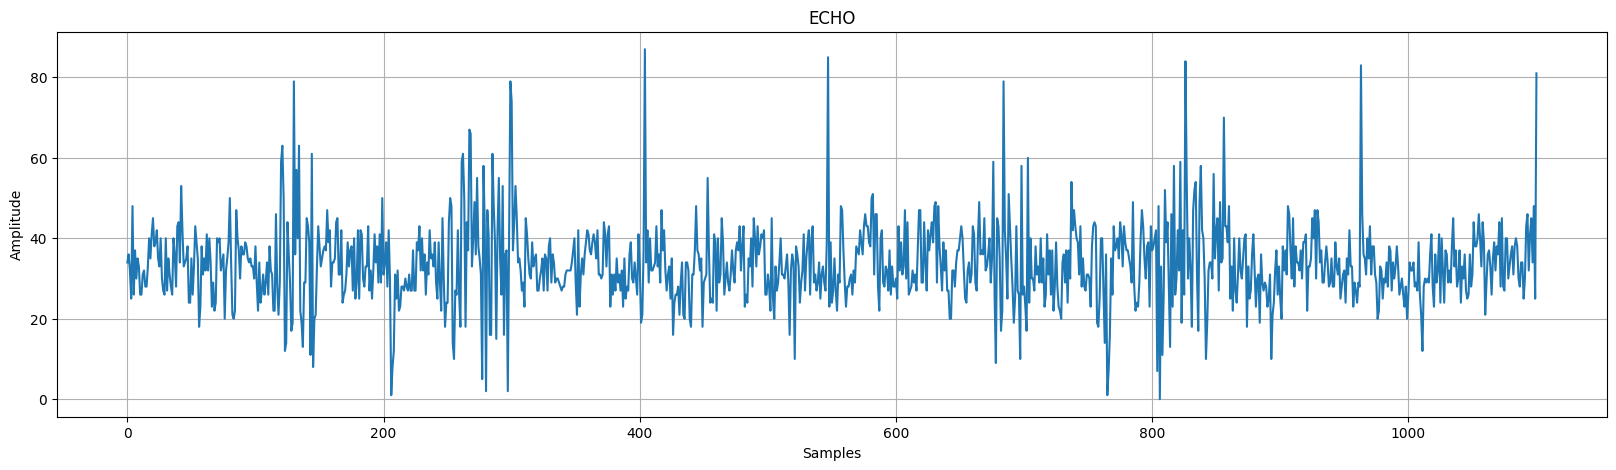

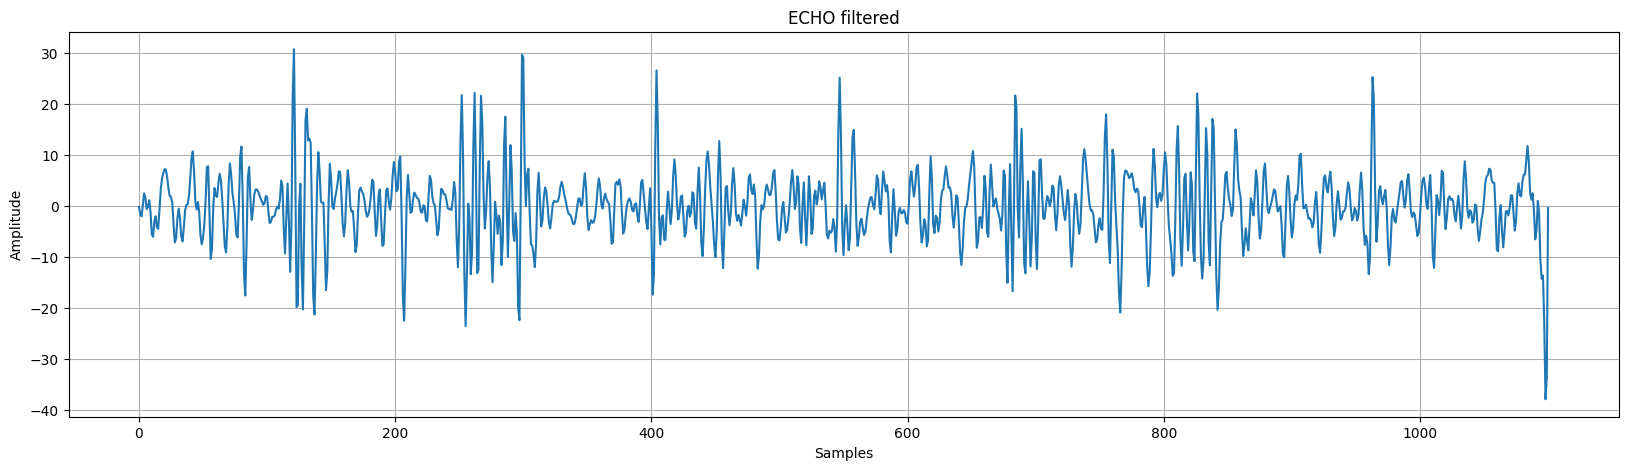

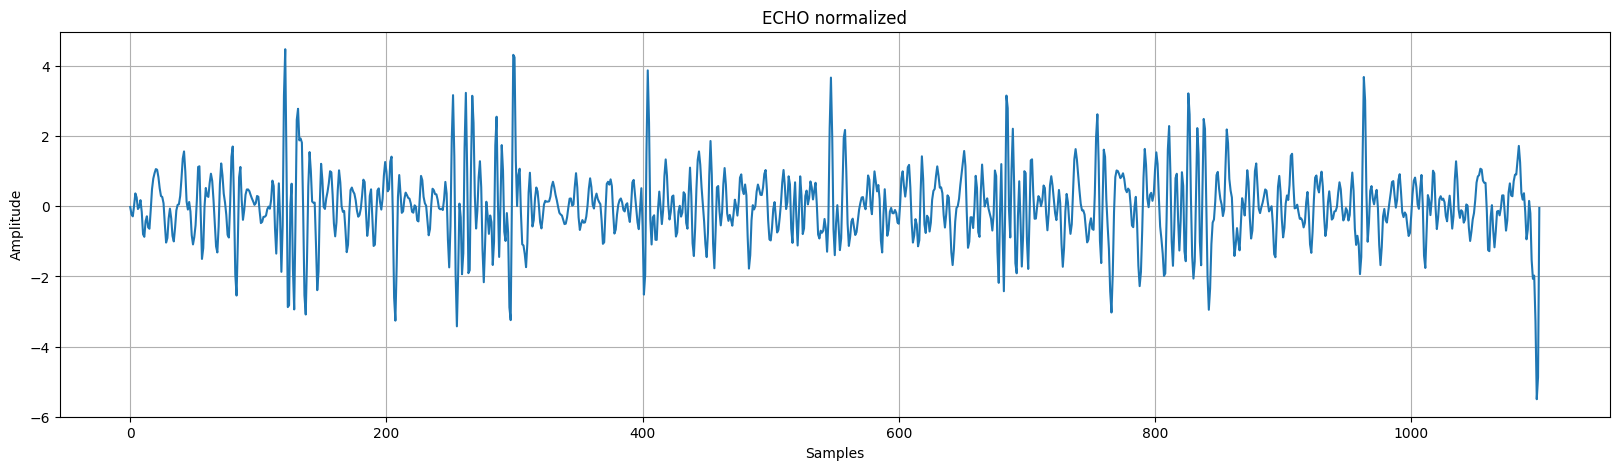

In [ ]:
ECHO=measures[1,3]
ECHO_time=ECHO['time']
ECHO_data=ECHO['data']
ECHO_data_value = ECHO_data[0, 0]
ECHO_data_value_channel_1 = ECHO_data_value[2, :, 0]

plt.figure(figsize=(20, 5))
plt.plot(ECHO_data_value_channel_1)
plt.title('ECHO')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

#Vamos a filtrar la señal
from scipy.signal import butter, filtfilt
#Butterworth de orden 4 con un ancho de banda de 25Hz a 200 Hz.
def filtro_pcg(ECHO_data_value_channel_1, fs, lowcut=25, highcut=200, order=4):
    nyquist = fs / 2
    b, a = butter(order, [lowcut / nyquist, highcut / nyquist], btype='band')
    return filtfilt(b, a, ECHO_data_value_channel_1)
fs=800
señal_filtrada=filtro_pcg(ECHO_data_value_channel_1, fs, lowcut=25, highcut=200, order=4)

plt.figure(figsize=(20, 5))
plt.plot(señal_filtrada)
plt.title('ECHO filtered')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

#Señal normalizada:
echo_normalized = normalize_zscore(señal_filtrada)

plt.figure(figsize=(20, 5))
plt.plot(echo_normalized)
plt.title('ECHO normalized')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

La normalización de la señal se realizará por el método

ECG

No está filtrado pero la calidad es muy buena

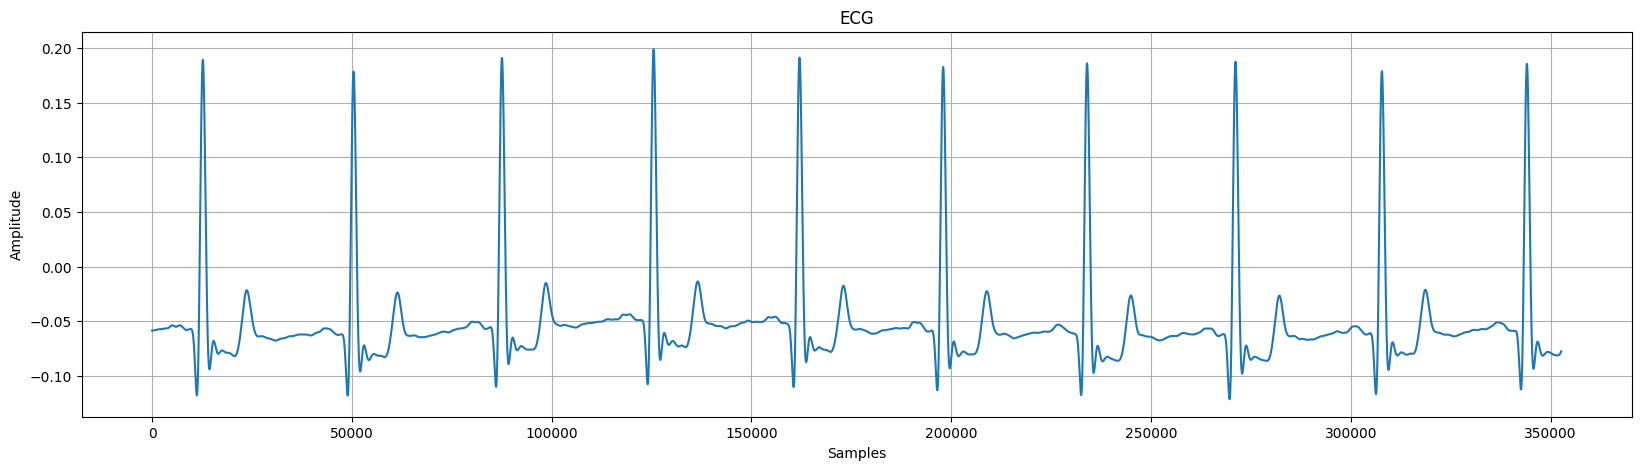

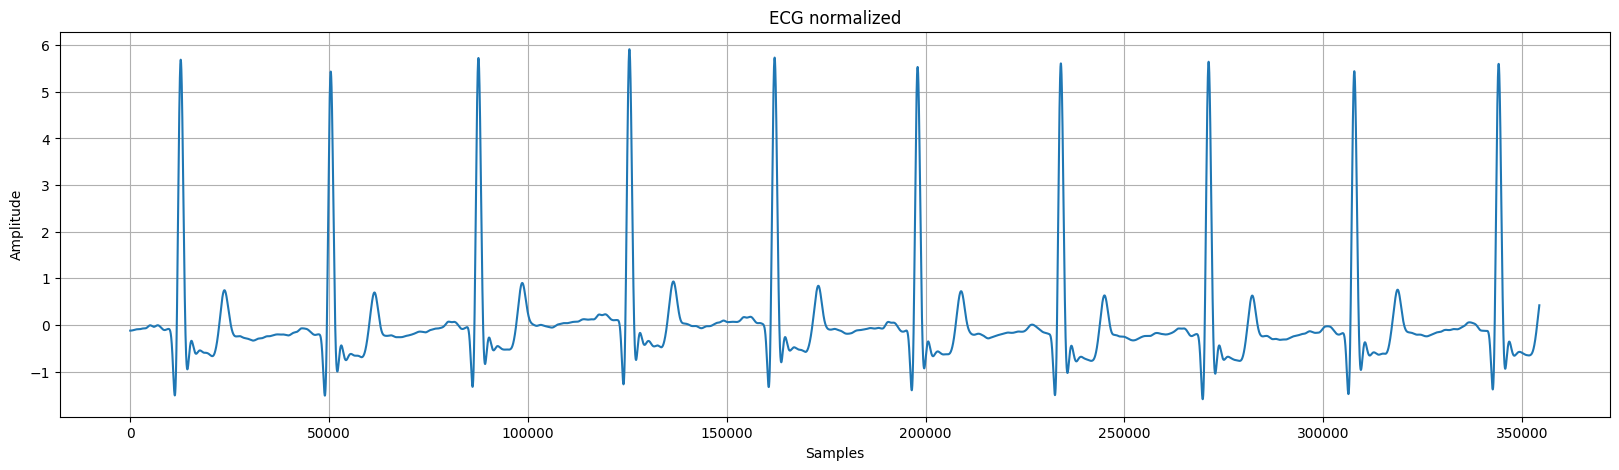

In [ ]:
ECG=measures[0,2]
ECG_time=ECG['time']
ECG_data=ECG['data']
ECG_data_value = ECG_data[0, 0]

plt.figure(figsize=(20, 5))
plt.plot(ECG_data_value[0:352661])
plt.title('ECG')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

#Señal normalizada:
ecg_normalized = normalize_zscore(ECG_data_value)

plt.figure(figsize=(20, 5))
plt.plot(ecg_normalized)
plt.title('ECG normalized')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

ICG FILTRADO

<class 'numpy.ndarray'>
(1, 1)


<ipython-input-31-9aea7370b075>:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  senal_filtrada[i] = error


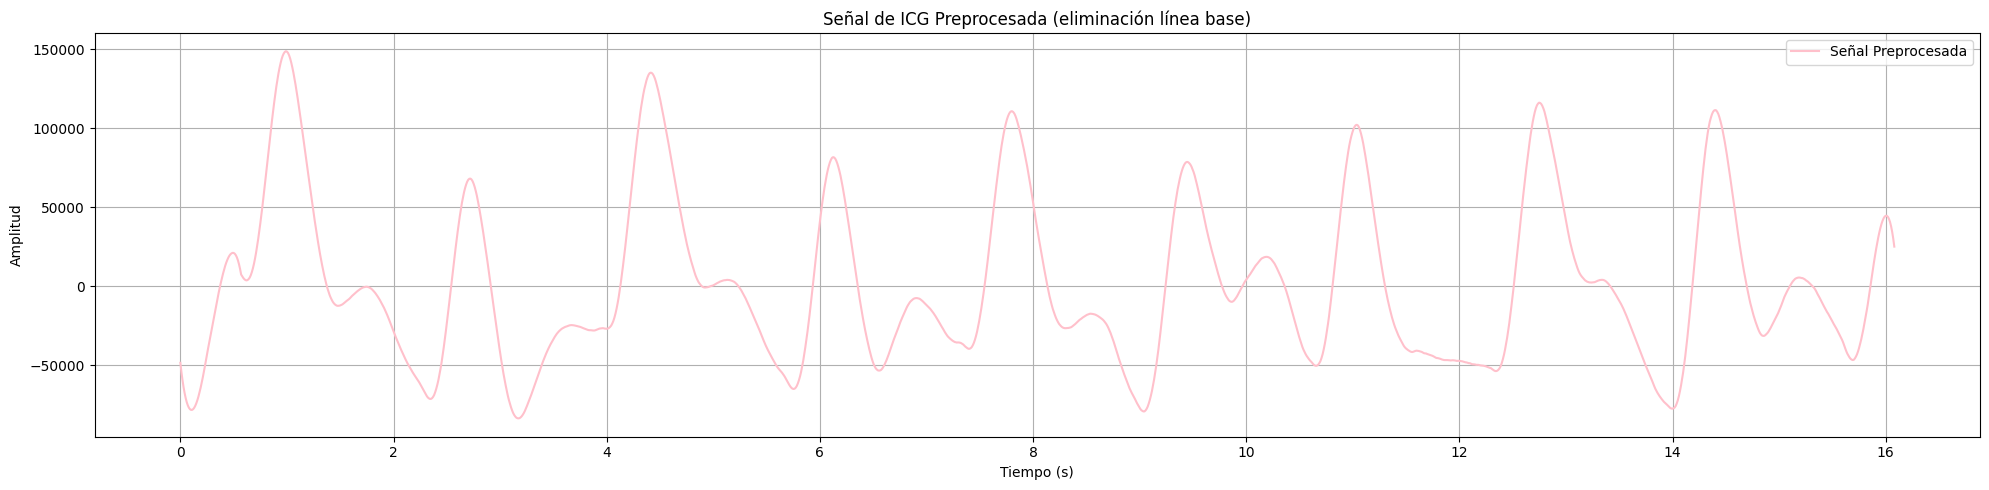

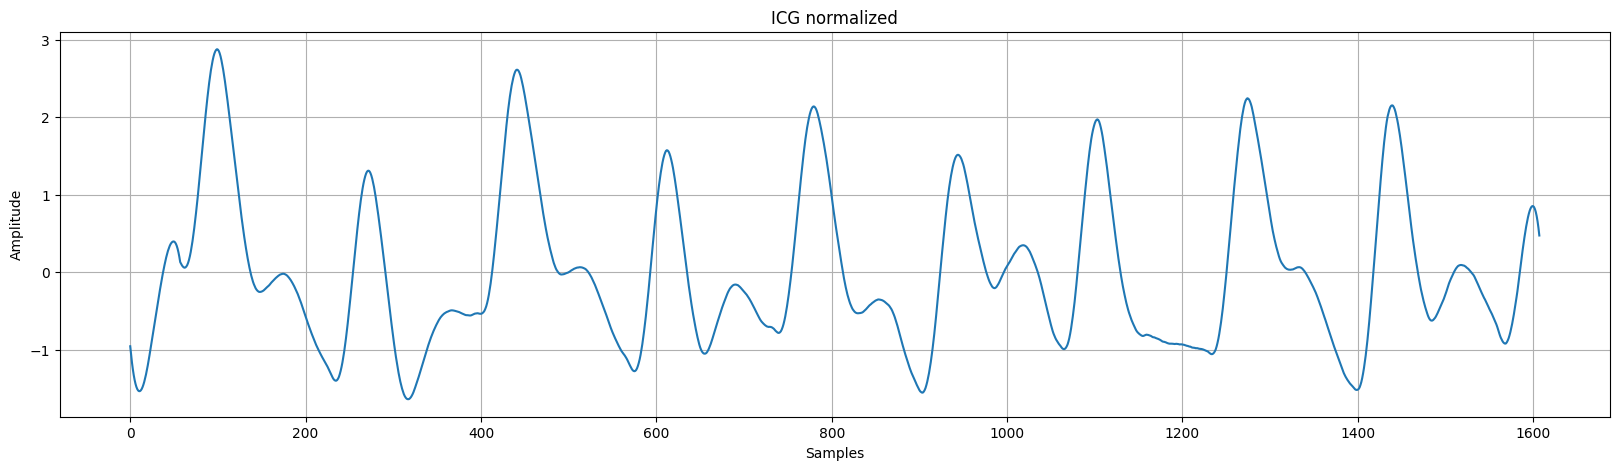

In [ ]:
impedance = measures[1,1]
impedance_time = impedance['time']
impedance_data = impedance['data']
print(type(impedance_data))
print(impedance_data.shape)  # Verificamos la forma de los datos

# Extraer los valores de impedancia
impedance_data_value = impedance_data[0, 0]  # Todos los datos están en [0,0]
impedance_data_value = impedance_data_value[0:1608]  # Tomamos un segmento

# Crear vector de tiempo (asumiendo fs=100Hz)
tiempo = np.linspace(0, len(impedance_data_value)/100, len(impedance_data_value))

# Generar señal de referencia (simulada)
np.random.seed(0)
senal_referencia = 0.1 * np.sin(2 * np.pi * 0.2 * tiempo) + 0.05 * np.random.normal(size=len(impedance_data_value))

# Filtro Adaptativo LMS (se mantiene igual)
def filtro_lms(impedance_data_value, senal_referencia, tasa_aprendizaje=0.01, orden_filtro=32):
    n_muestras = len(impedance_data_value)
    coeficientes = np.zeros(orden_filtro)
    senal_filtrada = np.zeros(n_muestras)

    for i in range(orden_filtro, n_muestras):
        ventana_referencia = senal_referencia[i - orden_filtro:i]
        estimacion = np.dot(coeficientes, ventana_referencia)
        error = impedance_data_value[i] - estimacion
        coeficientes += tasa_aprendizaje * error * ventana_referencia
        senal_filtrada[i] = error

    return senal_filtrada

# Aplicar filtro LMS
tasa_aprendizaje = 0.01
orden_filtro = 32
senal_filtrada_lms = filtro_lms(impedance_data_value, senal_referencia, tasa_aprendizaje, orden_filtro)

## NUEVO: Implementación del Filtro Savitzky-Golay
def filtro_savgol(senal, window_length=51, polyorder=3):

    return savgol_filter(senal, window_length, polyorder)

# Aplicar filtro SG con parámetros recomendados para ICG
window_length = 51  # Longitud de ventana (debe ser impar)
polyorder = 3  # Orden del polinomio (2 o 3)
senal_filtrada_sg = filtro_savgol(senal_filtrada_lms, window_length, polyorder)

def eliminar_linea_base(impedance_data_value, frecuencia_corte_baja, frecuencia_muestreo, orden=4):

    #Filtro pasa-altos para eliminar la línea base.
    b, a = butter(orden, frecuencia_corte_baja / (frecuencia_muestreo / 2), btype='high')
    return filtfilt(b, a, impedance_data_value)

frecuencia_corte_baja = 0.5  # Frecuencia de corte para eliminar la línea base (Hz)
frecuencia_muestreo = 200
senal_sin_linea_base = eliminar_linea_base(senal_filtrada_sg, frecuencia_corte_baja, frecuencia_muestreo)


# Graficar la señal
plt.figure(figsize=(20, 5))
plt.plot(tiempo, senal_sin_linea_base, label='Señal Preprocesada', color='pink')
plt.title('Señal de ICG Preprocesada (eliminación línea base)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Señal normalizada:
icg_normalized = normalize_zscore(senal_sin_linea_base)

plt.figure(figsize=(20, 5))
plt.plot(icg_normalized)
plt.title('ICG normalized')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

PCG

Comparación entre señal sin filtrar y señal filtrada


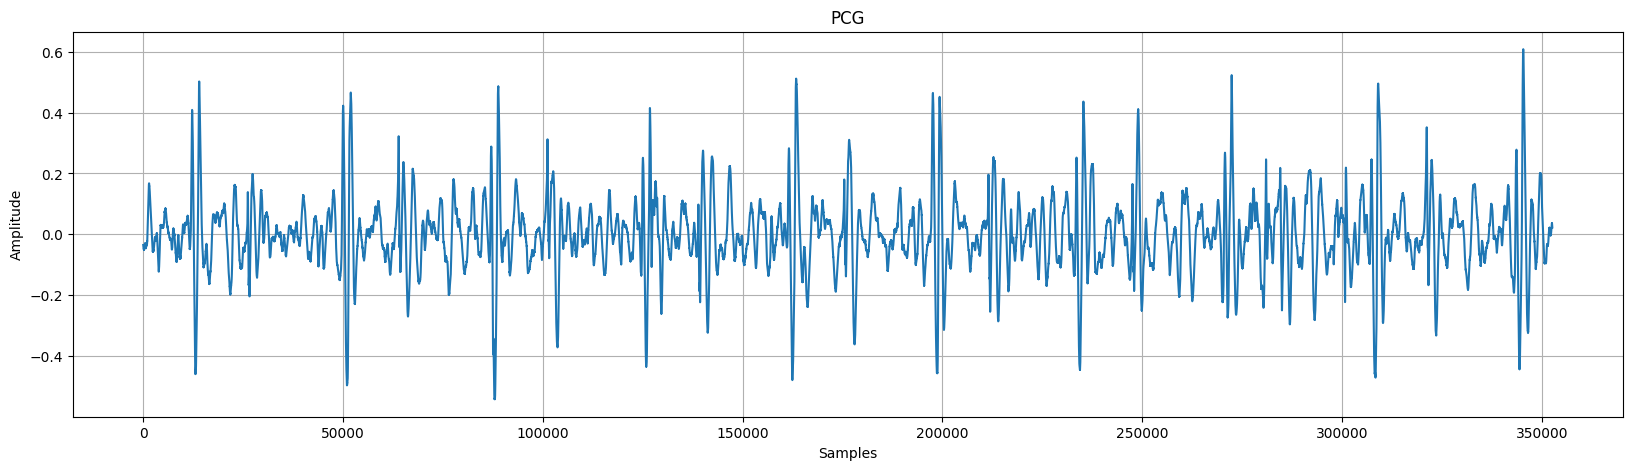

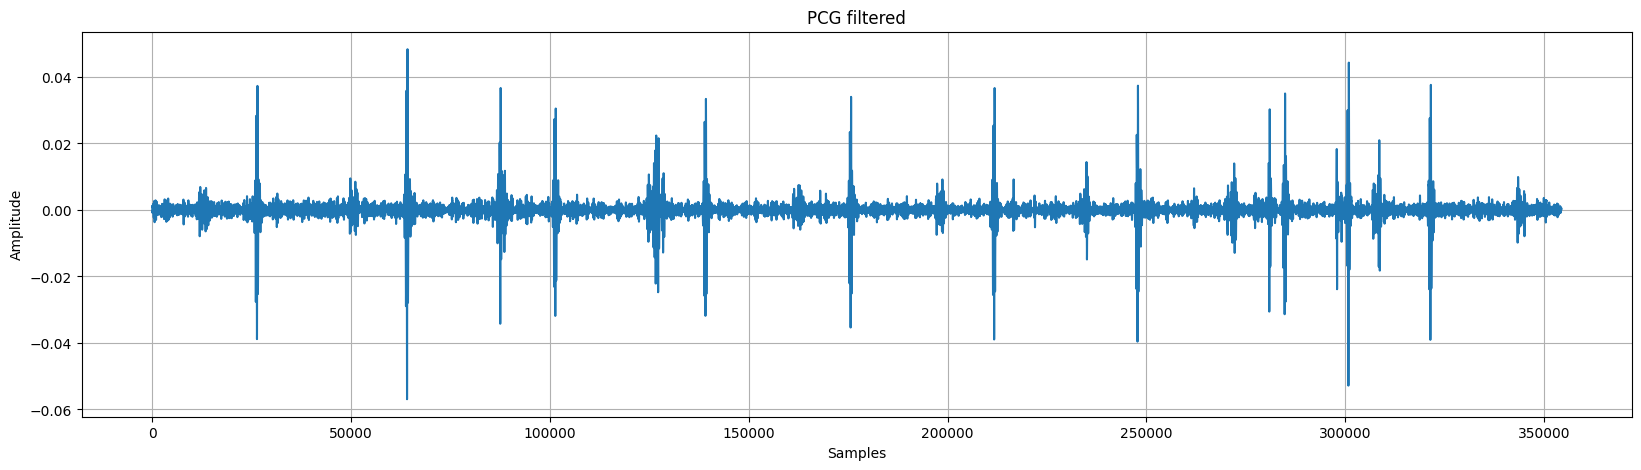

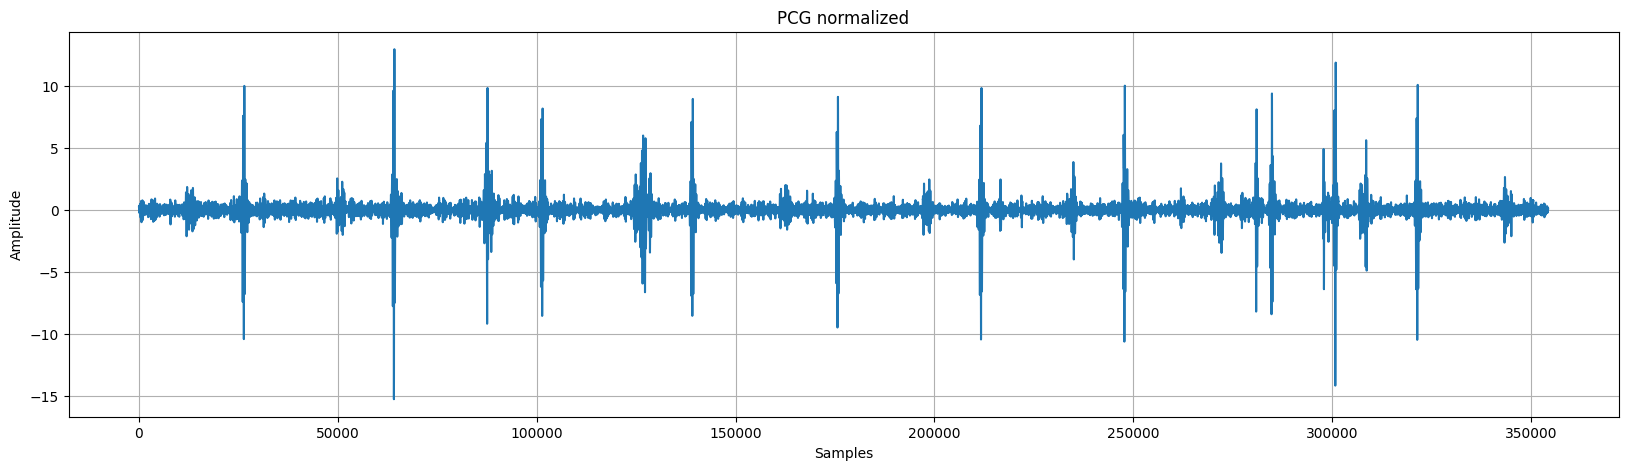

In [ ]:
PCG=measures[1,2]
PCG_time=PCG['time']
PCG_data=PCG['data']
PCG_data_value = PCG_data[0, 0]
PCG_signal = PCG_data_value.flatten()

plt.figure(figsize=(20, 5))
plt.plot(PCG_data_value[0:352660])
plt.title('PCG')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

#Vamos a filtrar la señal
from scipy.signal import butter, filtfilt
#Butterworth de orden 4 con un ancho de banda de 25Hz a 200 Hz.
def filtro_pcg(PCG_signal, fs, lowcut=25, highcut=200, order=4):
    nyquist = fs / 2
    b, a = butter(order, [lowcut / nyquist, highcut / nyquist], btype='band')
    return filtfilt(b, a, PCG_signal)
fs=8000
señal_filtrada=filtro_pcg(PCG_signal, fs, lowcut=25, highcut=200, order=4)

plt.figure(figsize=(20, 5))
plt.plot(señal_filtrada)
plt.title('PCG filtered')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

#Señal normalizada:
PCG_normalized = normalize_zscore(señal_filtrada)

plt.figure(figsize=(20, 5))
plt.plot(PCG_normalized)
plt.title('PCG normalized')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

PPG

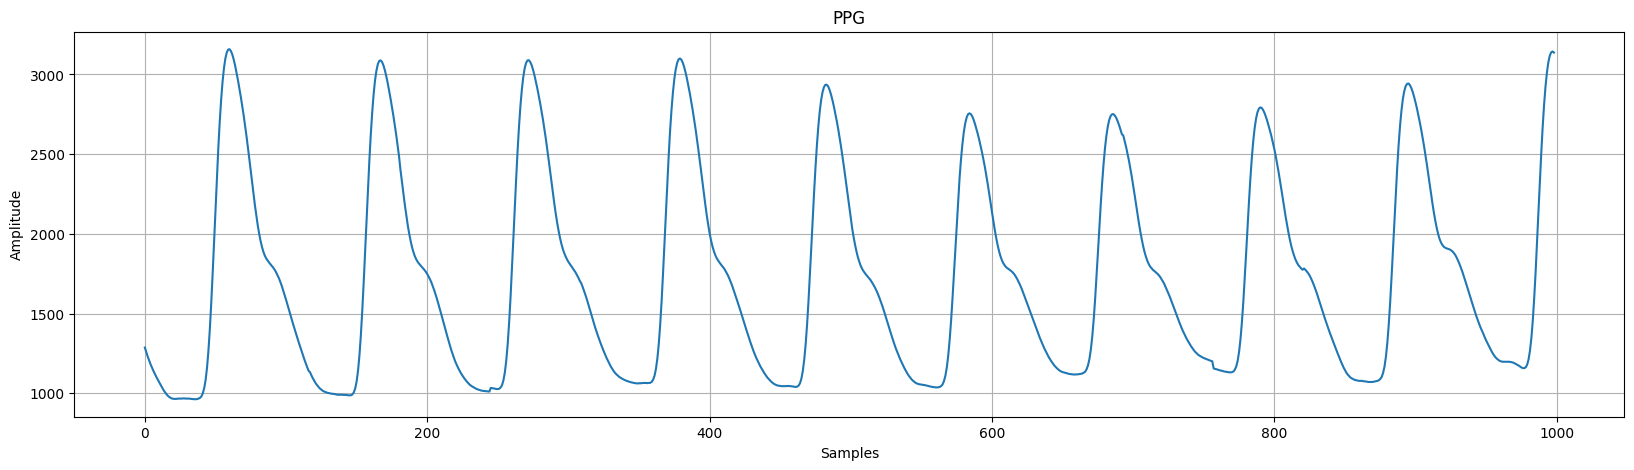

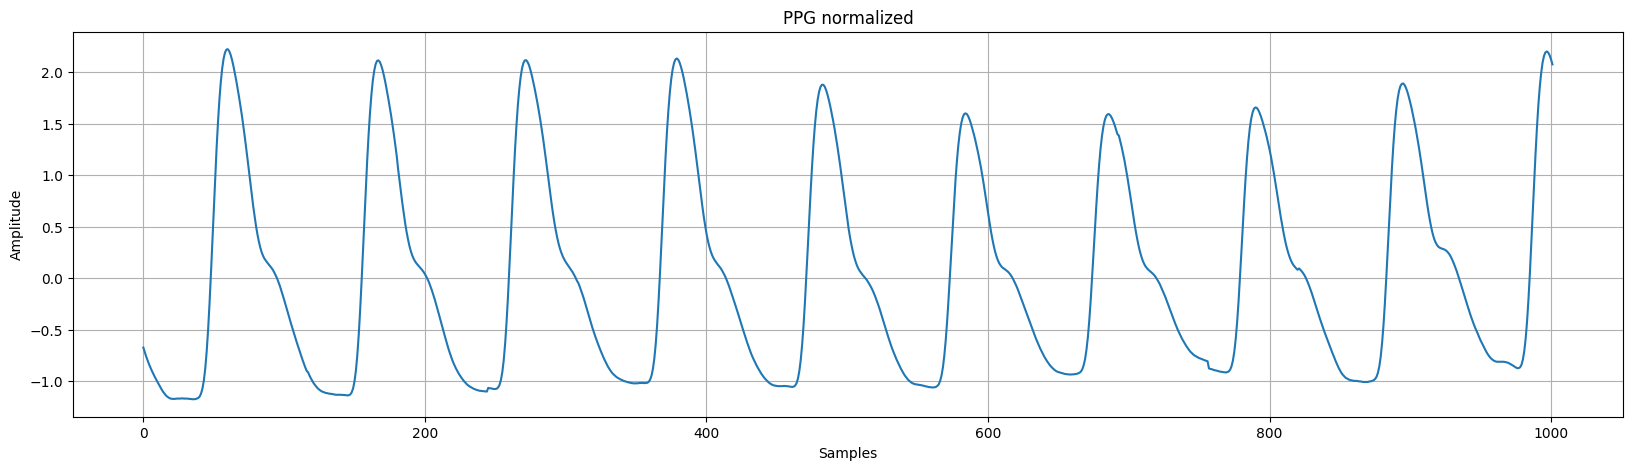

In [ ]:
PPG=measures[1,4]
PPG_time=PPG['time']
PPG_data=PPG['data']
PPG_data_value = PPG_data[0, 0]

plt.figure(figsize=(20, 5))
plt.plot(PPG_data_value[0:999])
plt.title('PPG')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

#Señal normalizada:
ppg_normalized = normalize_zscore(PPG_data_value)

plt.figure(figsize=(20, 5))
plt.plot(ppg_normalized)
plt.title('PPG normalized')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Calculamos el **coeficiente de correlación de Pearson** de cada una de las señales con respecto a ECHO.

**ECHO y ECG**:

In [ ]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

ECHO_data = ECHO['data'][0, 0]            # Get the data array
ECHO_signal = ECHO_data[2, :, 0].flatten() # Extract specific channel and flatten

ECG_data = ECG['data'][0, 0]              # Get the data array
ECG_signal = ECG_data.flatten()           # Flatten the ECG data

#This is done to ensure that both signals have the same length
min_length = min(len(ECHO_signal), len(ECG_signal))
ECHO_signal = ECHO_signal[:min_length]
ECG_signal = ECG_signal[:min_length]

# Calculate correlation
corr, pval = pearsonr(ECHO_signal, ECG_signal)

# 4. Print results
print(f"\nPearson correlation coefficient: {corr:.3f}")
print(f"p-value: {pval:.3e}")

# Interpretation
if pval < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p ≥ 0.05)")


Pearson correlation coefficient: 0.002
p-value: 9.579e-01
The correlation is not statistically significant (p ≥ 0.05)


Now, comparing the filtered and normalized signals

In [ ]:
import numpy as np
from scipy.stats import pearsonr

ECHO_signal = echo_normalized.flatten()
ECG_signal = ecg_normalized.flatten()

#This is done to ensure that both signals have the same length
min_length = min(len(ECHO_signal), len(ECG_signal))
ECHO_signal = ECHO_signal[:min_length]
ECG_signal = ECG_signal[:min_length]

# Calculate correlation
corr, pval = pearsonr(ECHO_signal, ECG_signal)

# 4. Print results
print(f"\nPearson correlation coefficient: {corr:.3f}")
print(f"p-value: {pval:.3e}")

# Interpretation
if pval < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p ≥ 0.05)")


Pearson correlation coefficient: -0.029
p-value: 3.383e-01
The correlation is not statistically significant (p ≥ 0.05)


Podemos observar que la correlación es bastante más elevada cuando ambas señales han sido filtradas y normalizadas.

**ECHO e ICG**:

In [ ]:
import numpy as np
from scipy.stats import pearsonr

# Ensure both are 1D arrays
echo_signal = np.array(ECHO_data_value_channel_1).flatten()
icg_signal = np.array(senal_sin_linea_base).flatten()

# Truncate to the same length
min_len = min(len(echo_signal), len(icg_signal))
echo_signal = echo_signal[:min_len]
icg_signal = icg_signal[:min_len]

# Calculate correlation
corr, pval = pearsonr(echo_signal, icg_signal)

# 4. Print results
print(f"\nPearson correlation coefficient: {corr:.3f}")
print(f"p-value: {pval:.3e}")

# Interpretation
if pval < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p ≥ 0.05)")


Pearson correlation coefficient: -0.007
p-value: 8.218e-01
The correlation is not statistically significant (p ≥ 0.05)


Now, comparing the filtered and normalized signals

In [ ]:
import numpy as np
from scipy.stats import pearsonr

# Ensure both are 1D arrays
ECHO_signal = echo_normalized.flatten()
icg_signal = icg_normalized.flatten()

# Truncate to the same length
min_len = min(len(echo_signal), len(icg_signal))
echo_signal = echo_signal[:min_len]
icg_signal = icg_signal[:min_len]

# Calculate correlation
corr, pval = pearsonr(echo_signal, icg_signal)

# 4. Print results
print(f"\nPearson correlation coefficient: {corr:.3f}")
print(f"p-value: {pval:.3e}")

# Interpretation
if pval < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p ≥ 0.05)")


Pearson correlation coefficient: -0.016
p-value: 6.231e-01
The correlation is not statistically significant (p ≥ 0.05)


**ECHO y PCG**:

In [ ]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

echo_signal = np.array(ECHO_data_value_channel_1).flatten()
pcg_signal = np.array(PCG_data_value[0:352660]).flatten() #we had .flatten() because pearsonr expects an 1D vector

#Truncate both signals to the same length
min_len = min(len(echo_signal), len(pcg_signal))
echo_signal = echo_signal[:min_len]
pcg_signal = pcg_signal[:min_len]

# Calculate correlation
corr, pval = pearsonr(echo_signal, pcg_signal)

# 4. Print results
print(f"\nPearson correlation coefficient: {corr:.3f}")
print(f"p-value: {pval:.3e}")

# Interpretation
if pval < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p ≥ 0.05)")



Pearson correlation coefficient: 0.021
p-value: 4.824e-01
The correlation is not statistically significant (p ≥ 0.05)


Now, comparing the filtered and normalized signals

In [ ]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

echo_signal = echo_normalized.flatten()
pcg_signal = np.array(PCG_normalized).flatten() #we had .flatten() because pearsonr expects an 1D vector

#Truncate both signals to the same length
min_len = min(len(echo_signal), len(pcg_signal))
echo_signal = echo_signal[:min_len]
pcg_signal = pcg_signal[:min_len]

# Calculate correlation
corr, pval = pearsonr(echo_signal, pcg_signal)

# 4. Print results
print(f"\nPearson correlation coefficient: {corr:.3f}")
print(f"p-value: {pval:.3e}")

# Interpretation
if pval < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p ≥ 0.05)")



Pearson correlation coefficient: -0.015
p-value: 6.226e-01
The correlation is not statistically significant (p ≥ 0.05)


**ECHO y PPG**:

In [ ]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

echo_signal = np.array(ECHO_data_value_channel_1).flatten()
ppg_signal = np.array(PPG_data_value[0:999]).flatten() #we had .flatten() because pearsonr expects an 1D vector

#Truncate both signals to the same length
min_len = min(len(echo_signal), len(ppg_signal))
echo_signal = echo_signal[:min_len]
ppg_signal = ppg_signal[:min_len]

# Calculate correlation
corr, pval = pearsonr(echo_signal, ppg_signal)

# 4. Print results
print(f"\nPearson correlation coefficient: {corr:.3f}")
print(f"p-value: {pval:.3e}")

# Interpretation
if pval < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p ≥ 0.05)")



Pearson correlation coefficient: 0.026
p-value: 4.133e-01
The correlation is not statistically significant (p ≥ 0.05)


Now, comparing the filtered and normalized signals

In [ ]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

echo_signal = echo_normalized.flatten()
ppg_signal = np.array(ppg_normalized).flatten() #we had .flatten() because pearsonr expects an 1D vector

#Truncate both signals to the same length
min_len = min(len(echo_signal), len(ppg_signal))
echo_signal = echo_signal[:min_len]
ppg_signal = ppg_signal[:min_len]

# Calculate correlation
corr, pval = pearsonr(echo_signal, ppg_signal)

# 4. Print results
print(f"\nPearson correlation coefficient: {corr:.3f}")
print(f"p-value: {pval:.3e}")

# Interpretation
if pval < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p ≥ 0.05)")



Pearson correlation coefficient: 0.001
p-value: 9.725e-01
The correlation is not statistically significant (p ≥ 0.05)


**Conclusiones que extraemos**:
Hemos calculado el coeficiente de correlación de Pearson de la señal ECHO con las 4 otras señales (ECG, ICG, PCG y PPG) y en todas ellas tenemos que no hay correlación ya que el valor del coeficiente es muy bajo. Creo que quizás el próximo paso podría ser filtrar todas las señales y volver a repetirlo.